In [1]:
# 1. 파이썬 코드에서 Matplotlib 폰트 설정
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from datetime import timedelta
from itertools import combinations
from collections import Counter

# 폰트 설정
plt.rc('font', family='Malgun Gothic')
# 마이너스 부호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

print("한글 폰트 설정이 완료되었습니다.")

# 3. 데이터 로드 및 통합 (모든 문제 풀이의 시작점)
try:
    orders_df = pd.read_csv('../data/orders.csv')
    payments_df = pd.read_csv('../data/payments.csv')
    products_df = pd.read_csv('../data/products.csv')
    shipping_df = pd.read_csv('../data/shipping.csv')
    customers_df = pd.read_csv('../data/customers.csv')

    # 모든 데이터프레임 병합
    df = pd.merge(orders_df, payments_df, on='order_id', how='left')
    df = pd.merge(df, products_df, on='product_id', how='left')
    df = pd.merge(df, customers_df, on='customer_id', how='left')
    df = pd.merge(df, shipping_df, on='order_id', how='left')

    # 데이터 전처리
    date_cols = ['order_date', 'payment_date', 'join_date', 'shipping_start_date', 'shipping_end_date']
    for col in date_cols:
        df[col] = pd.to_datetime(df[col], errors='coerce')
    df['total_sales'] = df['quantity'] * df['price']
    
    print("데이터 로드 및 통합이 완료되었습니다.")

except FileNotFoundError as e:
    print(f"파일을 찾을 수 없습니다: {e}")

한글 폰트 설정이 완료되었습니다.
데이터 로드 및 통합이 완료되었습니다.


In [2]:
# 문제 1: 배송사별 평균 배송 소요 시간(배송 시작~ 배송 완료)을 계산하고 비교하여 어느 배송사가 가장 빠른지 평가하세요.
# 시각화: 바 차트

# 비즈니스 목적: 물류 파트너(배송사)의 성과를 정량적으로 평가하여, 배송이 느린 업체를 교체하는 등의 의사결정에 활용합니다

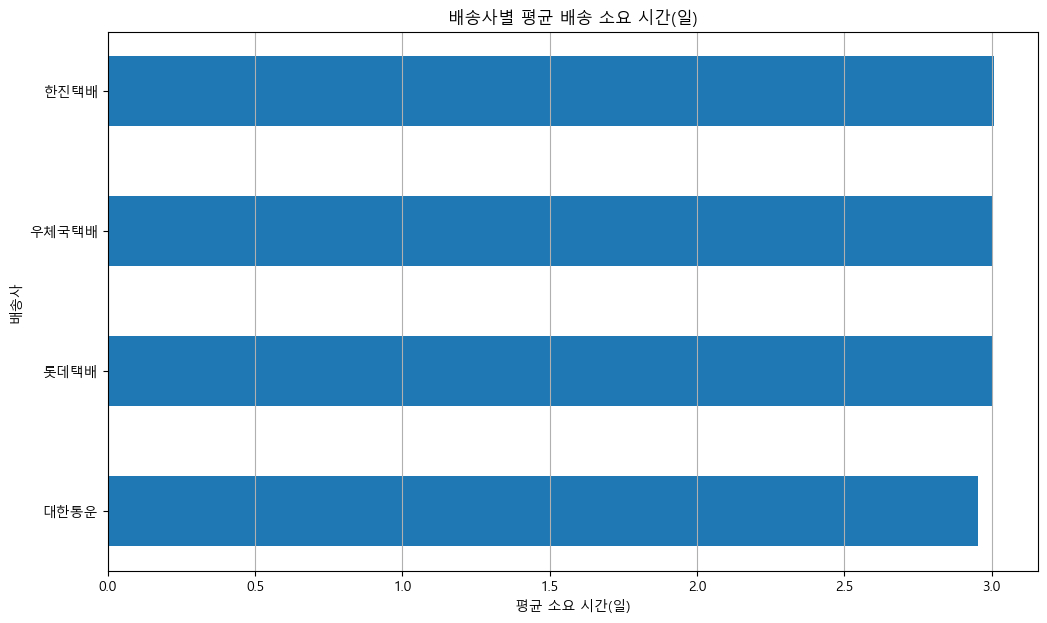

In [21]:
cols = ['shipping_company','shipping_start_date','shipping_end_date']

df_data1 = df[cols].copy()

df_data1['time_to_shipping'] = (df_data1['shipping_end_date'] - df_data1['shipping_start_date']).dt.days
shipping_duration = df_data1.groupby('shipping_company').mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(shipping_duration['shipping_company'], shipping_duration['time_to_shipping'],height=0.5)
ax.set_xlabel('평균 소요 시간(일)')
ax.set_ylabel('배송사')
ax.set_title('배송사별 평균 배송 소요 시간(일)')
ax.grid(axis='x')

plt.show()

In [ ]:
# 문제 2: 고객의 거주 도시를 수도권/비수도권으로 나누고, 지역별 평균 배송 소요 시간에 차이가 있는지 분석하세요.
# 비즈니스 목적: 특정 지역에서 배송 지연이 발생하고 있는지 파악하고,
# 해당 지역의 물류 파트너를 변경하거나 추가적인 물류, 거점을 확보하는 등의 전략을 수립합니다.
# 수도권 서울/경기 비수도권

region
비수도권    2.996013
수도권     2.984239
Name: time_to_shipping, dtype: float64


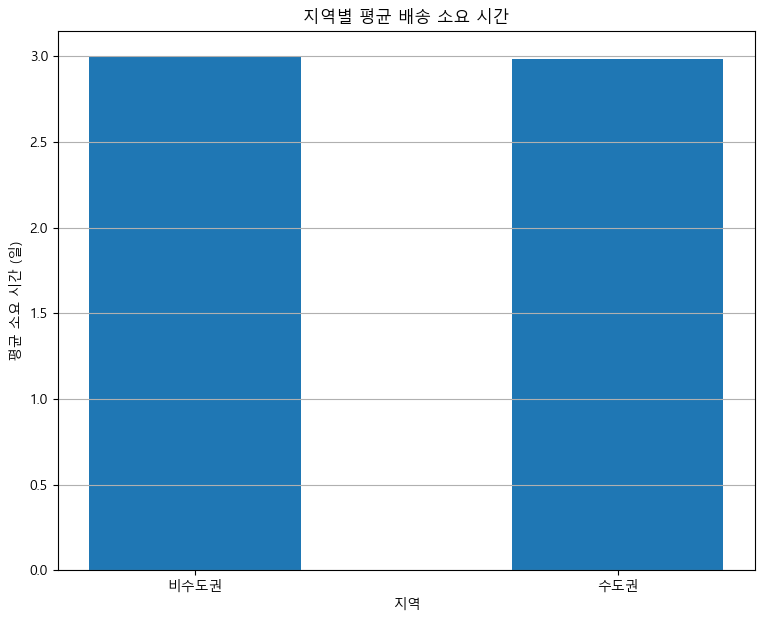

In [45]:
cols = ['city','shipping_start_date','shipping_end_date']

df_data2 = df[cols].copy()

df_data2['time_to_shipping'] = (df_data2['shipping_end_date'] - df_data2['shipping_start_date']).dt.days

metropolitan_keywords = ['서울', '경기', '인천']

def extract_province(city_name):
    # 시/군/구 이름에서 시도 추정
    if '서울' in city_name:
        return '서울'
    elif '인천' in city_name:
        return '인천'
    elif any(g in city_name for g in ['고양', '수원', '성남', '안양', '부천', '평택', '의정부', '광명', '하남', '이천', '용인', '남양주', '파주', '시흥', '군포', '의왕', '양주', '오산', '안성', '김포', '동두천', '과천', '연천', '가평', '양평']):
        return '경기'
    else:
        return '기타'

def classify_region(city_name):
    province = extract_province(city_name)
    return '수도권' if province in metropolitan_keywords else '비수도권'

df_data2['region'] = df_data2['city'].apply(classify_region)

region_stats = df_data2.groupby('region')['time_to_shipping'].mean()

print(region_stats)

fig, ax = plt.subplots(figsize=(9, 7))

bars = ax.bar(region_stats.index, region_stats.values, width=0.5)
ax.set_xlabel('지역')
ax.set_ylabel('평균 소요 시간 (일)')
ax.set_title('지역별 평균 배송 소요 시간')
ax.grid(True, axis='y')

<bound method IndexOpsMixin.value_counts of 0        안양시 만안구
1            청양군
2       고양시 일산동구
3            보령시
4            평택시
          ...   
9995         평택시
9996         청양군
9997         논산시
9998         이천시
9999         평창군
Name: city, Length: 10000, dtype: object>